# **Entrenamiento**

## Preprocesamiento del dataset

In [1]:
import pandas as pd
import random

archivo_positivas = 'positivas.txt' #Archivo con las 353 secuencias positivas
archivo_negativas = 'negativas.txt' #Archivo con las 5250 secuencias negativas

#Lectura de archivos, las secuencias se guardan en listas
with open(archivo_positivas, 'r') as f:
    secuencias_positivas = [linea.strip() for linea in f if linea.strip()]

with open(archivo_negativas, 'r') as f:
    secuencias_negativas = [linea.strip() for linea in f if linea.strip()]


In [ ]:
#Subsampleo aleatorio del conjunto negativo
random.seed(42)
negativas_balanceadas = random.sample(secuencias_negativas, len(secuencias_positivas))

print(f"Secuencias negativas después del undersampling: {len(negativas_balanceadas)}")

Secuencias negativas después del undersampling: 353


In [3]:
#Creación del dataframe con secuencias etiquetadas según el conjunto al que pertenecen
df_positivas = pd.DataFrame({
    'secuencia': secuencias_positivas,
    'etiqueta': 1
})

df_negativas = pd.DataFrame({
    'secuencia': negativas_balanceadas,
    'etiqueta': 0
})

df_final = pd.concat([df_positivas, df_negativas], ignore_index=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True) #Se revuelven las secuencias para que no esten en dos bloques grandes de positivas y negativas

# Ver un resumen del dataset final
print("\nDistribución del dataset final:")
print(df_final['etiqueta'].value_counts())
print("\nPrimeras 5 filas del dataset:")
print(df_final.head())

# Se guarda el dataset balanceado en un nuevo archivo CSV
df_final.to_csv('dataset_balanceado.csv', index=False)


Distribución del dataset final:
etiqueta
0    353
1    353
Name: count, dtype: int64

Primeras 5 filas del dataset:
                                           secuencia  etiqueta
0  MAGRTRIPFNGVGTSVLPAYQTLSAGQYLLSPNQRFKLLLQGDGNL...         0
1  VAPGVGVAPGVGVAPGVGVAPGVGVAPGVGVAPGVGVAPGVGVAPG...         1
2  TVPGVGTVPGVGTVPGVGTVPGVGTVPGVGTVPGVGTVPGVGTVPG...         1
3  MGKKTKRTADSSSSEDEEEYVVEKVLDRRVVKGQVEYLLKWKGFSE...         1
4  MSHVAVENALGLDQQFAGLDLNSSDNQSGGSTASKGRYIPPHLRNR...         1


## Vecorización

In [5]:
#pip install gensim

In [7]:
import numpy as np
from gensim.models import Word2Vec

#Division de la secuencia en 3-meros por recorrido de ventana
def generar_kmers(secuencia, k=3):
    return [secuencia[i:i+k] for i in range(len(secuencia) - k + 1)]

df_final['kmers'] = df_final['secuencia'].apply(generar_kmers)

df_final.head(3)

,secuencia,etiqueta,kmers,vector_final
0,MAGRTRIPFNGVGTSVLPAYQTLSAGQYLLSPNQRFKLLLQGDGNL...,0,"[MAG, AGR, GRT, RTR, TRI, RIP, IPF, PFN, FNG, ...","[-0.02040498069991826, 0.05897860921832804, -0..."
1,VAPGVGVAPGVGVAPGVGVAPGVGVAPGVGVAPGVGVAPGVGVAPG...,1,"[VAP, APG, PGV, GVG, VGV, GVA, VAP, APG, PGV, ...","[-0.08008743999242646, -0.0841337076564787, 0...."
2,TVPGVGTVPGVGTVPGVGTVPGVGTVPGVGTVPGVGTVPGVGTVPG...,1,"[TVP, VPG, PGV, GVG, VGT, GTV, TVP, VPG, PGV, ...","[-0.2197865238603356, 0.05394853485858566, -0...."


In [10]:
len(df_final['vector_final'][0])

200

In [ ]:
#Entrenamiento del modelo word2vec usando Gensim
#Parametros del paper: skip-gram (sg=1), ventana (window=8), dimensiones (vector_size=200), hierarchical softmax (hs=1)
w2v_model = Word2Vec(
    sentences=df_final['kmers'],
    vector_size=200, # cada k-mer = vector de 200 dimensiones
    window=8, # contexto de ±8 k-mers
    sg=1, # skip-gram: predice contexto a partir de una palabra
    hs=1, #usa hierarchical softmax en lugar de negative sampling
    negative = 0,
    min_count=1, # no descarta ningún k-mer
    seed=42
)

#Función matematica para la codificación posicional de Vaswani; permite que cada posición en la secuencia tenga una representación única que el modelo pueda aprender a interpretar
def obtener_vaswani_pe(longitud_secuencia, d_model=200):
    pe = np.zeros((longitud_secuencia, d_model))
    for pos in range(longitud_secuencia):
        for i in range(0, d_model, 2):
            theta = pos / (10000 ** (i / d_model))#formula de Vaswani con senos para índices pares y cosenos para impares
            pe[pos, i] = np.sin(theta)
            if i + 1 < d_model:
                pe[pos, i + 1] = np.cos(theta)
    return pe

#Función para unir word2vec y Vaswani en un solo vector por proteína
def vectorizar_proteina(kmers, modelo_w2v, d_model=200):
    seq_len = len(kmers)
    if seq_len == 0:
        return np.zeros(d_model)

    #Extraer los vectores word2vec de cada k-mero
    w2v_vectores = []
    for kmer in kmers:
        if kmer in modelo_w2v.wv:
            w2v_vectores.append(modelo_w2v.wv[kmer])
        else:
            w2v_vectores.append(np.zeros(d_model)) #se asigna cero a k-meros desconocidos
    w2v_vectores = np.array(w2v_vectores)
    pe_vectores = obtener_vaswani_pe(seq_len, d_model)
    vectores_combinados = w2v_vectores + pe_vectores #se suma la codificación posicional al vector de palabras
    vector_final = np.mean(vectores_combinados, axis=0) #se saca promedio para poder usarlo en GBDT

    return vector_final


df_final['vector_final'] = df_final['kmers'].apply(lambda x: vectorizar_proteina(x, w2v_model))
print("Dimensiones del primer vector:", df_final['vector_final'].iloc[0].shape)

Dimensiones del primer vector: (200,)


In [12]:
df_final['vector_final'][0]

array([-2.04049807e-02,  5.89786092e-02, -3.16743052e-02, -1.00362231e-02,
       -6.22761592e-02,  4.34630873e-02,  6.80357217e-03, -2.07540931e-02,
        4.22016432e-02,  4.31787055e-02, -1.03686324e-02,  3.12245934e-02,
       -3.86817047e-02, -9.26804859e-02, -1.36549452e-02,  5.05464232e-02,
        2.37496206e-02,  4.56109060e-02, -7.45345043e-02, -5.39257769e-02,
       -3.14170690e-02,  3.03446080e-02,  3.96517753e-02,  1.65156461e-03,
       -2.16238410e-02, -2.99787624e-03, -4.77017496e-02,  3.79314810e-02,
        4.12042319e-02, -4.00286345e-02,  9.43332305e-03,  2.07092231e-02,
       -6.10834386e-02, -6.72807943e-02,  8.62149079e-02,  9.05410199e-03,
       -2.94510634e-02,  5.10781481e-03,  1.69019703e-02, -7.19979523e-03,
       -5.96903003e-02,  9.35193750e-02,  7.53540185e-02, -2.92891149e-02,
       -5.81658472e-03, -7.72558594e-02, -5.66331676e-03,  7.30862650e-04,
        7.56043347e-02,  1.15946291e-02,  5.95894449e-02,  3.46727565e-02,
       -7.37649153e-03, -

## Entrenamiento y validación del modelo

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

#Matrices X (caracteristicas) e y (etiquetas)
X = np.vstack(df_final['vector_final'].values) #se apilan los vectores que tenemos en las filas para crear una matriz 2D (706x200)
y = df_final['etiqueta'].values

#Inicialización del modelo GBDT con parámetros estándar
gbdt_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

#Configuración de la validación cruzada con 10 folds
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) #cada partición se mantiene en la misma proporción de proteínas positivas y negativas

#Definición de las métricas de validación
scoring = ['accuracy', 'f1', 'precision', 'recall']

cv_results = cross_validate(gbdt_model, X, y, cv=cv, scoring=scoring)

print("Resultados de la Validación Cruzada (10 folds):")
print(f"Accuracy promedio:  {np.mean(cv_results['test_accuracy']):.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")
print(f"F1 Score promedio:  {np.mean(cv_results['test_f1']):.4f} (+/- {np.std(cv_results['test_f1']):.4f})")
print(f"Precisión promedio: {np.mean(cv_results['test_precision']):.4f} (+/- {np.std(cv_results['test_precision']):.4f})")
print(f"Recall (Sensitividad): {np.mean(cv_results['test_recall']):.4f} (+/- {np.std(cv_results['test_recall']):.4f})")

#Entrenamiento del modelo final con todo el conjunto de datos
modelo_final = gbdt_model.fit(X, y)
print("\nModelo final entrenado")

Resultados de la Validación Cruzada (10 folds):
Accuracy promedio:  0.9618 (+/- 0.0190)
F1 Score promedio:  0.9610 (+/- 0.0197)
Precisión promedio: 0.9740 (+/- 0.0203)
Recall (Sensitividad): 0.9488 (+/- 0.0280)

Modelo final entrenado


## Clasificación del proteoma de N.crassa

In [14]:
#pip install biopython

In [17]:
from Bio import SeqIO

#Función para leer el FASTA y extraer los id's y las secuencias
def leer_fasta_a_dataframe(archivo_fasta):
    datos = []
    #SeqIO.parse lee el archivo reconociendo automáticamente los símbolos ">"
    for registro in SeqIO.parse(archivo_fasta, "fasta"):
        datos.append({
            'id_proteina': registro.id,
            'secuencia': str(registro.seq)
        })
    return pd.DataFrame(datos)

#Carga del proteoma de N. crassa
archivo_nuevas = 'proteoma_ncrassa.fasta'
df_nuevas = leer_fasta_a_dataframe(archivo_nuevas)
print(f"Cargadas {len(df_nuevas)} secuencias")
print(df_nuevas.head(3))

Cargadas 10255 secuencias
            id_proteina                                          secuencia
0  sp|A7UX13|EGT2_NEUCR  MVATTVELPLQQKADAAQTVTGPLPFGNSLLKEFVLDPAYRNLNHG...
1  sp|P00411|COX2_NEUCR  MGLLFNNLIMNFDAPSPWGIYFQDSATPQMEGLVELHDNIMYYLVV...
2  sp|P00440|TYRO_NEUCR  MSTDIKFAITGVPTPPSSNGAVPLRRELRDLQQNYPEQFNLYLLGL...


In [18]:
#Preprocesamiento
df_nuevas['kmers'] = df_nuevas['secuencia'].apply(generar_kmers) #se generan lo 3-meros de cada secuencia para vectorizarlos
df_nuevas['vector_final'] = df_nuevas['kmers'].apply(lambda x: vectorizar_proteina(x, w2v_model)) #se aplica la vecotorizacion con w2v

X_nuevas = np.vstack(df_nuevas['vector_final'].values)

#Predicción
df_nuevas['prediccion_clase'] = modelo_final.predict(X_nuevas)
df_nuevas['probabilidad_LLPS'] = modelo_final.predict_proba(X_nuevas)[:, 1]

#Guardar y exportar los resultados incluyendo el id
columnas_finales = ['id_proteina', 'secuencia', 'prediccion_clase', 'probabilidad_LLPS']
df_nuevas = df_nuevas.sort_values(by='probabilidad_LLPS', ascending=False) #ordenados por probabilidad


In [ ]:
df_nuevas.head(3)

,id_proteina,secuencia,kmers,vector_final,prediccion_clase,probabilidad_LLPS
6027,tr|Q7S252|Q7S252_NEUCR,MLIHCISSRPSHIFPALLLLLLIYWLCLWVKMDQSLRLAGTPARVI...,"[MLI, LIH, IHC, HCI, CIS, ISS, SSR, SRP, RPS, ...","[-0.030109366391632, 0.062183003024244315, -0....",0,0.000947
7188,tr|Q7S8I5|Q7S8I5_NEUCR,MDLHRRVQSQTSSTSTATPSKHAFETRVADVKSPKSDINALILDYL...,"[MDL, DLH, LHR, HRR, RRV, RVQ, VQS, QSQ, SQT, ...","[0.016685435559395327, 0.03694516095799675, -0...",0,0.000947
3901,tr|A7UWI4|A7UWI4_NEUCR,MSIQLSELVLSTFSNGLDTLSHIIDVAEQYASSQGLSADAEYPNAR...,"[MSI, SIQ, IQL, QLS, LSE, SEL, ELV, LVL, VLS, ...","[0.004110070502633249, 0.03732573166893484, -0...",0,0.000947


## Comparación con el predictor parSe v2

In [32]:
import pandas as pd
import re
from collections import defaultdict
import numpy as np

In [ ]:
# Leer regiones PS IDR y organizarlas por proteína
file_path = "parSe v2/NCRASSA_filtered.FASTA"
psidr_dict = defaultdict(list)

with open(file_path, "r") as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i].strip()

    if line.startswith(">"):
        # ejemplo:
        # > uniprot: P07509, residues: 44-98
        match = re.search(r'uniprot:\s*(\w+),\s*residues:\s*(\d+)-(\d+)', line)

        if match:
            protein_id = match.group(1)
            start = int(match.group(2))
            end = int(match.group(3))

            psidr_dict[protein_id].append((start, end))

        i += 2  # saltar secuencia
    else:
        i += 1


In [ ]:
# Crear los features
# IDR (Intrinsically Disordered Region):
# - región de la proteína que no tiene una estructura tridimensional fija, lo que le permite ser flexible y participar en interacciones dinámicas.
# - no se pliega como hélice o lámina beta
# PS IDRs = regiones desordenadas con potencial de separación de fases

data = []

for protein_id, regions in psidr_dict.items():

    lengths = [(end - start + 1) for start, end in regions]

    total_length = sum(lengths)
    max_length = max(lengths)
    n_regions = len(regions)

    data.append({
        "id_proteina": protein_id,
        "n_regions": n_regions,
        "total_psidr_length": total_length,
        "max_psidr_length": max_length
    })

df_psidr = pd.DataFrame(data)

print(df_psidr.head())

#lengths → tamaño de cada región
#total_length → cuánto espacio total ocupan las PS IDRs
#max_length → la región más larga
#n_regions → cuántas regiones hay

  id_proteina  n_regions  total_psidr_length  max_psidr_length
0      P07509          1                  55                55
1      P08619          1                  62                62
2      P0C581          2                 125                71
3      P19212          6                 553               144
4      P19970          2                 148                83


In [ ]:
# Modificación para poder hacer el merge
df_nuevas["id_proteina_clean"] = df_nuevas["id_proteina"].apply(
    lambda x: x.split("|")[1] if "|" in x else x
)

In [38]:
df_nuevas.head(5)

,id_proteina,secuencia,kmers,vector_final,prediccion_clase,probabilidad_LLPS,id_proteina_clean
6398,tr|Q7S443|Q7S443_NEUCR,MAGPRAPIGTLSQHAANAAALARNTSTNVFSQQKSQLKSKKGKQEE...,"[MAG, AGP, GPR, PRA, RAP, API, PIG, IGT, GTL, ...","[0.028669564717384844, 0.07171628564260973, -0...",1,0.999439,Q7S443
6091,tr|Q7S2H4|Q7S2H4_NEUCR,MPGPRRLLQQASSLLLVVVALSATTVSAVPASQLFQRQSTSTCAAE...,"[MPG, PGP, GPR, PRR, RRL, RLL, LLQ, LQQ, QQA, ...","[-0.036769084318509435, 0.06947764149395964, -...",1,0.999276,Q7S2H4
9186,tr|V5IL59|V5IL59_NEUCR,MNMNNMGNMAQMNAMGGPVGGAPMPMMNNGAMPVRPQQPPQPQPQQ...,"[MNM, NMN, MNN, NNM, NMG, MGN, GNM, NMA, MAQ, ...","[-0.026942195942046474, 0.016397011108421393, ...",1,0.999212,V5IL59
6233,tr|Q7S3A2|Q7S3A2_NEUCR,MTDTMSFQYPPPPSQNGTDMDIQHSGYMPYSVPPPGSDLRHSPDMG...,"[MTD, TDT, DTM, TMS, MSF, SFQ, FQY, QYP, YPP, ...","[-0.007329157902172369, 0.030794845132861855, ...",1,0.999200,Q7S3A2
4573,tr|Q1K754|Q1K754_NEUCR,MSGTMSKRQQARNEKVLHELAQAPGNNVCADCSARNPTWASWSLGI...,"[MSG, SGT, GTM, TMS, MSK, SKR, KRQ, RQQ, QQA, ...","[0.00762079669090051, 0.005198405752391994, -0...",1,0.999182,Q1K754


In [39]:
df_final = df_nuevas.merge(
    df_psidr,
    left_on="id_proteina_clean",
    right_on="id_proteina",
    how="left"
)

df_final["n_regions"] = df_final["n_regions"].fillna(0)
df_final["total_psidr_length"] = df_final["total_psidr_length"].fillna(0)
df_final["max_psidr_length"] = df_final["max_psidr_length"].fillna(0)

print(df_final.head(5))

            id_proteina_x                                          secuencia  \
0  tr|Q7S443|Q7S443_NEUCR  MAGPRAPIGTLSQHAANAAALARNTSTNVFSQQKSQLKSKKGKQEE...   
1  tr|Q7S2H4|Q7S2H4_NEUCR  MPGPRRLLQQASSLLLVVVALSATTVSAVPASQLFQRQSTSTCAAE...   
2  tr|V5IL59|V5IL59_NEUCR  MNMNNMGNMAQMNAMGGPVGGAPMPMMNNGAMPVRPQQPPQPQPQQ...   
3  tr|Q7S3A2|Q7S3A2_NEUCR  MTDTMSFQYPPPPSQNGTDMDIQHSGYMPYSVPPPGSDLRHSPDMG...   
4  tr|Q1K754|Q1K754_NEUCR  MSGTMSKRQQARNEKVLHELAQAPGNNVCADCSARNPTWASWSLGI...   

                                               kmers  \
0  [MAG, AGP, GPR, PRA, RAP, API, PIG, IGT, GTL, ...   
1  [MPG, PGP, GPR, PRR, RRL, RLL, LLQ, LQQ, QQA, ...   
2  [MNM, NMN, MNN, NNM, NMG, MGN, GNM, NMA, MAQ, ...   
3  [MTD, TDT, DTM, TMS, MSF, SFQ, FQY, QYP, YPP, ...   
4  [MSG, SGT, GTM, TMS, MSK, SKR, KRQ, RQQ, QQA, ...   

                                        vector_final  prediccion_clase  \
0  [0.028669564717384844, 0.07171628564260973, -0...                 1   
1  [-0.036769084318509435, 0.06947

## Comparaciones de resultados

In [ ]:
# Correlaciones
# n_regions → cuántas PS IDRs tiene la proteína
# total_psidr_length → cuánto ocupan en total
# max_psidr_length → tamaño de la más grande

cols = [
    "n_regions",
    "total_psidr_length",
    "max_psidr_length"
]

for col in cols:
    corr = df_final["probabilidad_LLPS"].corr(df_final[col])
    print(f"{col}: {corr:.4f}")


n_regions: 0.5058
total_psidr_length: 0.4691
max_psidr_length: 0.4844


In [41]:
print("\n=== MUCHAS REGIONES (ParSe alto) ===")
print(df_final.sort_values("n_regions", ascending=False)[
    ["id_proteina_clean", "probabilidad_LLPS", "n_regions"]
].head(10))


=== MUCHAS REGIONES (ParSe alto) ===
     id_proteina_clean  probabilidad_LLPS  n_regions
312             Q7RXD0           0.997021        8.0
633             P19212           0.994764        6.0
225             V5IRR4           0.997570        6.0
11              Q7SH96           0.998957        5.0
116             V5IN25           0.998098        5.0
83              V5INC5           0.998314        5.0
517             Q7RZC6           0.995684        5.0
1484            Q01631           0.975926        5.0
770             Q7SDG2           0.993331        5.0
48              Q7SC11           0.998583        4.0


In [42]:
#Las proteínas con más regiones PS IDR según ParSe y cómo las califica el modelo
print(df_final.sort_values("n_regions", ascending=False)[
    ["id_proteina_clean", "probabilidad_LLPS", "n_regions"]
].head(10))

     id_proteina_clean  probabilidad_LLPS  n_regions
312             Q7RXD0           0.997021        8.0
633             P19212           0.994764        6.0
225             V5IRR4           0.997570        6.0
11              Q7SH96           0.998957        5.0
116             V5IN25           0.998098        5.0
83              V5INC5           0.998314        5.0
517             Q7RZC6           0.995684        5.0
1484            Q01631           0.975926        5.0
770             Q7SDG2           0.993331        5.0
48              Q7SC11           0.998583        4.0


In [ ]:
# Modelo con probabilidades altas pero pocas regiones PS IDR
print(df_final.sort_values("n_regions", ascending=False)[
    ["id_proteina_clean", "probabilidad_LLPS", "n_regions"]
].head(10))


     id_proteina_clean  probabilidad_LLPS  n_regions
312             Q7RXD0           0.997021        8.0
633             P19212           0.994764        6.0
225             V5IRR4           0.997570        6.0
11              Q7SH96           0.998957        5.0
116             V5IN25           0.998098        5.0
83              V5INC5           0.998314        5.0
517             Q7RZC6           0.995684        5.0
1484            Q01631           0.975926        5.0
770             Q7SDG2           0.993331        5.0
48              Q7SC11           0.998583        4.0


In [44]:
# ParSe ALTO, MODELO BAJO
print("\n=== MODELO BAJO, ParSe ALTO ===")
print(df_final[
    (df_final["n_regions"] > 3) &
    (df_final["probabilidad_LLPS"] < 0.2)
][["id_proteina_clean", "probabilidad_LLPS", "n_regions"]].head(10))


=== MODELO BAJO, ParSe ALTO ===
Empty DataFrame
Columns: [id_proteina_clean, probabilidad_LLPS, n_regions]
Index: []


In [46]:
#pip install matplotlib seaborn matplotlib-venn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45440 sha256=5d63d694c1a21fad61b4bb7b346b0c8289be9463db027b038ac7f7f615d6869e
  Stored in directory: c:\users\jazmin\appdata\local\pip\cache\wheels\d1\5f\e6\771479559f992b8398265ebf61f8a3d33ca0b8f75552e06ad2
Successfully built matplotlib-venn
Note: you may need to restart the kernel to use updated packages.


C:\Users\Jazmin\AppData\Local\Temp\ipykernel_8884\1946738086.py:24: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


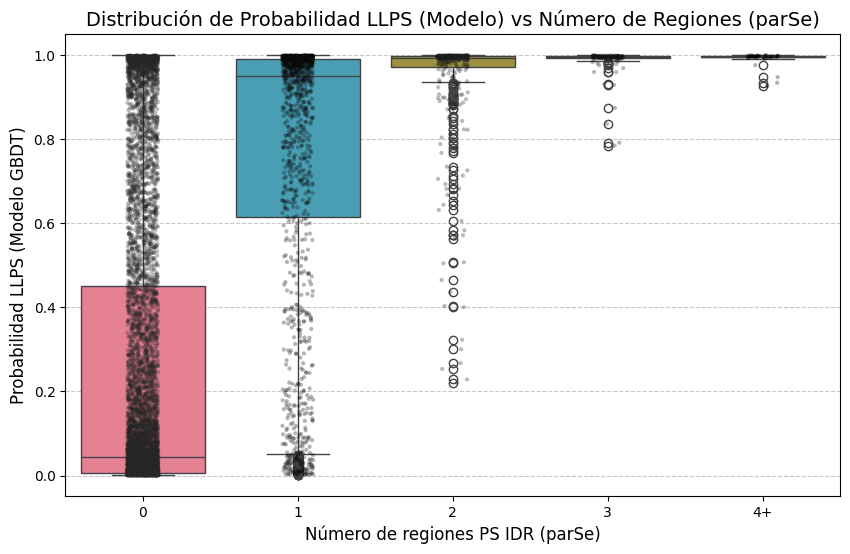

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear una nueva columna categórica para agrupar 4 o más regiones
df_final['n_regions_cat'] = df_final['n_regions'].apply(lambda x: '4+' if x >= 4 else str(int(x)))

# Definir el orden de las categorías en el eje X
orden_categorias = ['0', '1', '2', '3', '4+']

# 2. Configurar y crear el gráfico
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_final, 
    x='n_regions_cat', 
    y='probabilidad_LLPS', 
    order=orden_categorias, 
    hue='n_regions_cat',   
    legend=False,         
    palette='husl'      
)

# Añadir los puntos reales encima de las cajas
sns.stripplot(
    data=df_final, 
    x='n_regions_cat', 
    y='probabilidad_LLPS', 
    order=orden_categorias, 
    hue='n_regions_cat', 
    legend=False,
    color='black',         
    alpha=0.3, 
    size=3
)

# 3. Etiquetas y título
plt.title('Distribución de Probabilidad LLPS (Modelo) vs Número de Regiones (parSe)', fontsize=14)
plt.xlabel('Número de regiones PS IDR (parSe)', fontsize=12)
plt.ylabel('Probabilidad LLPS (Modelo GBDT)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

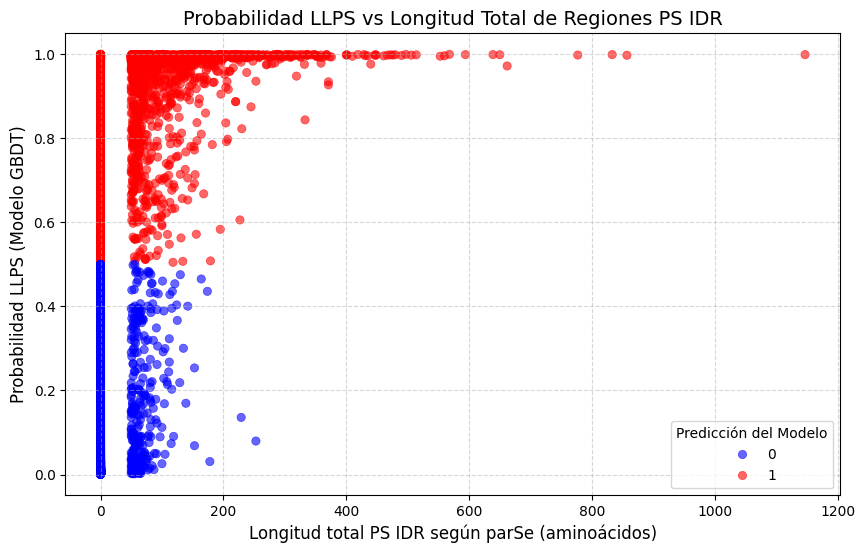

In [48]:
plt.figure(figsize=(10, 6))

# Crear el diagrama de dispersión
sns.scatterplot(
    data=df_final, 
    x='total_psidr_length', 
    y='probabilidad_LLPS', 
    hue='prediccion_clase', # Colorea según si el modelo predijo 0 o 1
    palette={0: 'blue', 1: 'red'}, # Azul para negativas, rojo para positivas
    alpha=0.6, # Transparencia para ver puntos superpuestos
    edgecolor=None
)

# Etiquetas y título
plt.title('Probabilidad LLPS vs Longitud Total de Regiones PS IDR', fontsize=14)
plt.xlabel('Longitud total PS IDR según parSe (aminoácidos)', fontsize=12)
plt.ylabel('Probabilidad LLPS (Modelo GBDT)', fontsize=12)

# Mover la leyenda a un lugar que no estorbe
plt.legend(title='Predicción del Modelo', loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

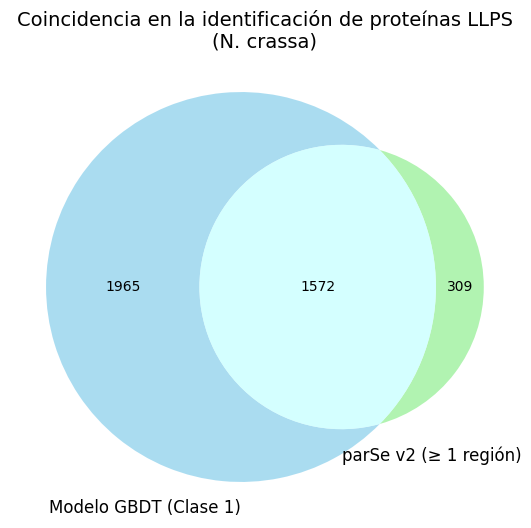

In [49]:
from matplotlib_venn import venn2

# 1. Definir los conjuntos (sets) usando los IDs de las proteínas
# Conjunto A: Proteínas que el modelo predijo como positivas (LLPS)
set_modelo = set(df_final[df_final['prediccion_clase'] == 1]['id_proteina_clean'])

# Conjunto B: Proteínas que parSe dice que tienen al menos 1 región
set_parse = set(df_final[df_final['n_regions'] > 0]['id_proteina_clean'])

# 2. Configurar el gráfico
plt.figure(figsize=(8, 6))

# Crear el diagrama de Venn
venn = venn2(
    [set_modelo, set_parse], 
    set_labels=('Modelo GBDT (Clase 1)', 'parSe v2 (≥ 1 región)'),
    set_colors=('skyblue', 'lightgreen'),
    alpha=0.7
)

plt.title('Coincidencia en la identificación de proteínas LLPS\n(N. crassa)', fontsize=14)

plt.show()